   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



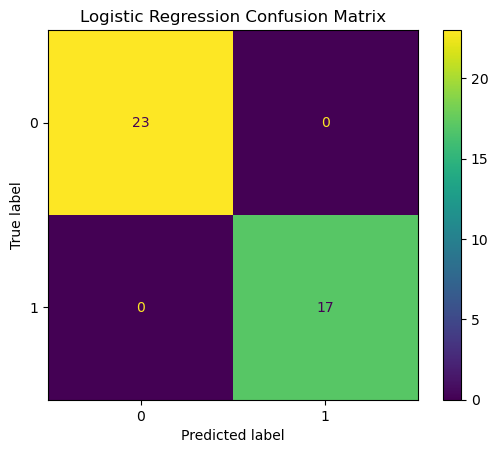

Decision Tree Accuracy: 1.0

Feature Importance:
Age: 0.0295
Annual Income (k$): -0.2274
Spending Score (1-100): 4.3716
Gender: -0.0390


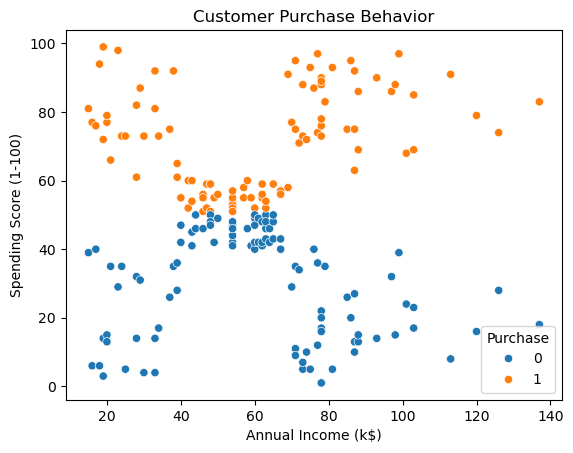

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Preview
print(data.head())

# Convert categorical column (Gender) to numeric
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Create target variable
data['Purchase'] = data['Spending Score (1-100)'].apply(lambda x: 1 if x > 50 else 0)

# Features and target
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']]
y = data['Purchase']

# 🔹 Feature Scaling (correct place)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================
# 🔹 Logistic Regression Model
# ==============================
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ==============================
# 🔹 Decision Tree Model
# ==============================
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

# ==============================
# 🔹 Feature Importance (Logistic Regression)
# ==============================
importance = lr_model.coef_[0]
features = X.columns

print("\nFeature Importance:")
for f, i in zip(features, importance):
    print(f"{f}: {i:.4f}")

# ==============================
# 🔹 Visualization
# ==============================
sns.scatterplot(
    x=data['Annual Income (k$)'],
    y=data['Spending Score (1-100)'],
    hue=data['Purchase']
)

plt.title("Customer Purchase Behavior")
plt.show()